
# Python: Projeto Final - EBAC
Python para analise de dados - Modulo 11

Aluno: João Paulo Costa

---------------------------------------

# Tópicos



1.   Breve descrição do problema;
2.   Importação de bibliotecas;
3.   Carregamento/Geração de dados;
4.   Exploração dos dados;
5.   Limpeza e transformação dos dados;
6.   Análise dos dados;
7.   Conclusão









# 1\.Breve descrição do problema

Com base na exploraçao dos dados de crédito presentes neste neste [link](https://raw.githubusercontent.com/andre-marcos-perez/ebac-course-utils/develop/dataset/credito.csv). (Os dados estão no formato CSV e contém informações sobre clientes de uma instituição financeira). Tenho como ponto de interesse, explicar a segunda coluna, chamada de **default**, que indica se um cliente é adimplente(`default = 0`), ou inadimplente (`default = 1`), ou seja, o objetivo é entender o porque um cliente se torna inamdiplente, baseado no comportamento de outros atributos, como salário, escolaridade e movimentação financeira.

Uma descrição completa dos atributos está abaixo.




| Coluna  | Descrição |
| ------- | --------- |
| id      | Número da conta |
| default | Indica se o cliente é adimplente (0) ou inadimplente (1) |
| idade   | --- |
| sexo    | --- |
| depedentes | --- |
| escolaridade | --- |
| estado_civil | --- |
| salario_anual | Faixa do salario mensal multiplicado por 12 |
| tipo_cartao | Categoria do cartao: blue, silver, gold e platinium |
| meses_de_relacionamento | Quantidade de meses desde a abertura da conta |
| qtd_produtos | Quantidade de produtos contratados |
| iteracoes_12m | Quantidade de iteracoes com o cliente no último ano |
| meses_inatico_12m | Quantidade de meses que o cliente ficou inativo no último ano |
| limite_credito | Valor do limite do cartão de crédito |
| valor_transacoes_12m | Soma total do valor das transações no cartão de crédito no último ano |
| qtd_transacoes_12m | Quantidade total de transações no cartão de crédito no último ano |



> Em resumo a **variável resposta** em questão é o atributo (`default`), e os demais atributos (`idade`, `salário`, etc.) as **variáveis explicatívas**

# 2\. Exploração dos dados

### 2.1.Importação de Bibliotecas

Começamos com a importação das bibliotecas que serão utilizadas, `pandas` para a exploração dos dados; `seaborn` e `matplotlib`, para a analise e visualização dos mesmos, `numpy`,`typing` e `warnings` foram usados na construção das funções untilizadas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List
import warnings
sns.set_style("whitegrid")

### 2.2. Carregamento e geração dos dados

Seguimos com o extração dos dados do arquivo 'credito.csv', através do `pandas`, salvamos em um `dataframe` e fazemos a verificação dos dados recebidos, gerandos eles em nosso ambiente.

In [2]:
df = pd.read_csv('/kaggle/input/credito/credito.csv', na_values='na')
#Usaremos 'na' como padrão para que o pandas entenda algum possivel dado vazio

In [3]:
df.head(n=10)

,id,default,idade,sexo,dependentes,escolaridade,estado_civil,salario_anual,tipo_cartao,meses_de_relacionamento,qtd_produtos,iteracoes_12m,meses_inativo_12m,limite_credito,valor_transacoes_12m,qtd_transacoes_12m
0,768805383,0,45,M,3,ensino medio,casado,$60K - $80K,blue,39,5,3,1,"12.691,51","1.144,90",42
1,818770008,0,49,F,5,mestrado,solteiro,menos que $40K,blue,44,6,2,1,"8.256,96","1.291,45",33
2,713982108,0,51,M,3,mestrado,casado,$80K - $120K,blue,36,4,0,1,"3.418,56","1.887,72",20
3,769911858,0,40,F,4,ensino medio,NaN,menos que $40K,blue,34,3,1,4,"3.313,03","1.171,56",20
4,709106358,0,40,M,3,sem educacao formal,casado,$60K - $80K,blue,21,5,0,1,"4.716,22","816,08",28
5,713061558,0,44,M,2,mestrado,casado,$40K - $60K,blue,36,3,2,1,"4.010,69","1.088,07",24
6,810347208,0,51,M,4,NaN,casado,$120K +,gold,46,6,3,1,"34.516,72","1.330,87",31
7,818906208,0,32,M,0,ensino medio,NaN,$60K - $80K,silver,27,2,2,2,"29.081,49","1.538,32",36
8,710930508,0,37,M,3,sem educacao formal,solteiro,$60K - $80K,blue,36,5,0,2,"22.352,50","1.350,14",24
9,719661558,0,48,M,2,mestrado,solteiro,$80K - $120K,blue,36,6,3,3,"11.656,41","1.441,73",32


Para começarmos, vamos verificar o balançeamento dos nossos dados, a proporção de clientes adimplentes e inadimplentes:

In [4]:
qtd_total, _ = df.shape
#Extraindo a quantidade de linhas e colunas totais do nosso dataframe e salvando em uma variavel para uso futuro

qtd_adimplentes, _ = df[df['default'] == 0].shape
#Extraindo a quantidade de linhas referentes aos clientes adimplentes e salvando em uma variavel para uso futuro

qtd_inadimplentes, _ = df[df['default'] == 1].shape
#Extraindo a quantidade de linhas referentes aos clientes inadimplentes e salvando em uma variavel para uso futuro

print(f"A proporcão clientes adimplentes é de {round(100 * qtd_adimplentes / qtd_total, 2)}%")
print(f"A proporcão clientes inadimplentes é de {round(100 * qtd_inadimplentes / qtd_total, 2)}%")
#Verificando dos dados coletados

A proporcão clientes adimplentes é de 83.93%
A proporcão clientes inadimplentes é de 16.07%


### 2.3.Schema

Agora vamos fazer a relação entre os dados de nossas colunas com os seus tipos, para que observemos se existe algum erro, ou inconsistência com o tipo de dado referente e a natureza da coluna.

In [5]:
df.dtypes

id                          int64
default                     int64
idade                       int64
sexo                       object
dependentes                 int64
escolaridade               object
estado_civil               object
salario_anual              object
tipo_cartao                object
meses_de_relacionamento     int64
qtd_produtos                int64
iteracoes_12m               int64
meses_inativo_12m           int64
limite_credito             object
valor_transacoes_12m       object
qtd_transacoes_12m          int64
dtype: object

Aqui ja podemos ver que e há inconsistencias, as colunas de `limite_credito` e `valor_transacoes_12m` estão com tipo `object`, ou seja, uma `str`, mas o correto seria que apresentassem o typo `float64`, pois estamos trabalhando com valores.

Se fizermos a impressão da descrição dessas colunas por atributo, podemos confimar isso, sabendo que: atribuitos categóricos: Possui tipo `object` atributos numéricos: Possui tipo `number`

In [6]:
df.select_dtypes('object').describe().transpose() #Atributos catégoricos

,count,unique,top,freq
sexo,10127,2,F,5358
escolaridade,8608,5,mestrado,3128
estado_civil,9378,3,casado,4687
salario_anual,9015,5,menos que $40K,3561
tipo_cartao,10127,4,blue,9436
limite_credito,10127,9272,"1.438,21",11
valor_transacoes_12m,10127,10035,"3.851,51",3


In [7]:
df.drop('id', axis=1).select_dtypes('number').describe().transpose() #Atributos numericos
#Fazemos o 'drop' da coluna de 'id' pois não faremos uso dela

,count,mean,std,min,25%,50%,75%,max
default,10127.0,0.160660,0.367235,0.0,0.0,0.0,0.0,1.0
idade,10127.0,46.325960,8.016814,26.0,41.0,46.0,52.0,73.0
dependentes,10127.0,2.346203,1.298908,0.0,1.0,2.0,3.0,5.0
meses_de_relacionamento,10127.0,35.928409,7.986416,13.0,31.0,36.0,40.0,56.0
qtd_produtos,10127.0,3.812580,1.554408,1.0,3.0,4.0,5.0,6.0
iteracoes_12m,10127.0,2.455317,1.106225,0.0,2.0,2.0,3.0,6.0
meses_inativo_12m,10127.0,2.341167,1.010622,0.0,2.0,2.0,3.0,6.0
qtd_transacoes_12m,10127.0,64.858695,23.472570,10.0,45.0,67.0,81.0,139.0


Com essas duas descições podemos confimar que as colunas de `limite_credito` e `valor_transacoes_12m` estão com tipo `object`, pois estão descritos nos atributos catégoricos.

E podemos perceber também que existem dados faltando: as colunas de `escolaridade`, `estado_civil` e `salario_anual`, apresentam uma contagem menor de elementos que o total do nosso `dataframe`.

Podemos confirmar isso, verificando quais colunas possuem dados faltantes

In [8]:
df.isna().any()

id                         False
default                    False
idade                      False
sexo                       False
dependentes                False
escolaridade                True
estado_civil                True
salario_anual               True
tipo_cartao                False
meses_de_relacionamento    False
qtd_produtos               False
iteracoes_12m              False
meses_inativo_12m          False
limite_credito             False
valor_transacoes_12m       False
qtd_transacoes_12m         False
dtype: bool

Confirmadas as colunas com dados faltantes, vamos levantar algumas estatisticas sobre essas colunas, para saber como esses dados faltantes podem ou não afetar no nosso objetivo

In [9]:
def qtd_dados_faltantes(df: pd.DataFrame) -> None: #Criamos uma função para separar e ler esses dados

  qtd_dados_faltantes = []
  for col in df.columns:
    if df[col].isna().any():
      qtd, _ = df[df[col].isna()].shape
      total, _ = df.shape
      dic_dados_faltantes = {col:{'Quantidade:': qtd, 'Porcentagem': round(100 * qtd / total, 2)}}
      qtd_dados_faltantes.append(dic_dados_faltantes)

  for dic in qtd_dados_faltantes:
    print(dic)

#Imprimimos esses dados, organizadamente, para compará-los
print('Quantidade total de dados faltantes por coluna:')
qtd_dados_faltantes(df=df)
print('\n')

print('Quantidade de dados faltantes, nos considerados adimplentes:')
qtd_dados_faltantes(df=df[df['default'] == 0])
print('\n')

print('Quantidade de dados faltantes, nos considerados inadimplentes:')
qtd_dados_faltantes(df=df[df['default'] == 1])

Quantidade total de dados faltantes por coluna:
{'escolaridade': {'Quantidade:': 1519, 'Porcentagem': 15.0}}
{'estado_civil': {'Quantidade:': 749, 'Porcentagem': 7.4}}
{'salario_anual': {'Quantidade:': 1112, 'Porcentagem': 10.98}}


Quantidade de dados faltantes, nos considerados adimplentes:
{'escolaridade': {'Quantidade:': 1263, 'Porcentagem': 14.86}}
{'estado_civil': {'Quantidade:': 620, 'Porcentagem': 7.29}}
{'salario_anual': {'Quantidade:': 925, 'Porcentagem': 10.88}}


Quantidade de dados faltantes, nos considerados inadimplentes:
{'escolaridade': {'Quantidade:': 256, 'Porcentagem': 15.73}}
{'estado_civil': {'Quantidade:': 129, 'Porcentagem': 7.93}}
{'salario_anual': {'Quantidade:': 187, 'Porcentagem': 11.49}}


Aqui podemos notar que a proporção de dados faltantes praticamente não varia, para os três atributos, nos três Data Frames analisados (`df original completo`, `df de adimplentes` e `df de inadimplentes`). Assim, concluimos que  podemos eliminar as linhas com dados faltantes sem que criemos um problema na análise dos dados.

# 3\. Limpeza e transformação dos dados

Agora que exploramos os nossos dados, e encontramos neles problemas que precisam ser corrigidos, vamos prosseguir para essas correções

### 3.1.Correção de schema

Anteriormente na exploração, notamos que as colunas `limite_credito` e `valor_transacoes_12m`, estão sendo interpretadas como colunas categóricas (`dtype = object`). Mas precimos que sejam reconhecidas como numericas.

Então vamos fazer a conversão desses dados

In [10]:
df[['limite_credito', 'valor_transacoes_12m']].head(n=5)

,limite_credito,valor_transacoes_12m
0,"12.691,51","1.144,90"
1,"8.256,96","1.291,45"
2,"3.418,56","1.887,72"
3,"3.313,03","1.171,56"
4,"4.716,22","816,08"


Puxamos a infomação de 5 linhas das colunas que queremos trabalhar, para usarmos como teste.

Vamos então criar uma função para limpar esses dados e testaremos nessa lista de 5 elementos, para que tenhamos certeza que irá funcionar, antes de usarmos em todo o Data Frame

In [11]:
valores_originais = ['12.691,51', '8.256,96', '3.418,56', '3.313,03', '4.716,22']
valores_limpos = list(map(lambda valor: float(valor.replace(".", "").replace(",", ".")), valores_originais))

print(f'Valores Originais:{valores_originais}')
print(f'Valores Limpos:{valores_limpos}')

Valores Originais:['12.691,51', '8.256,96', '3.418,56', '3.313,03', '4.716,22']
Valores Limpos:[12691.51, 8256.96, 3418.56, 3313.03, 4716.22]


Com a função `lambda` de conversão, funcionando corretamente, vamos aplica-lá nas colunas de interesse

In [12]:
df['valor_transacoes_12m'] = df['valor_transacoes_12m'].apply(lambda valor: float(valor.replace(".", "").replace(",", ".")))
df['limite_credito'] = df['limite_credito'].apply(lambda valor: float(valor.replace(".", "").replace(",", ".")))

Agora vamos ver novamente nosso schema

In [13]:
df.dtypes

id                           int64
default                      int64
idade                        int64
sexo                        object
dependentes                  int64
escolaridade                object
estado_civil                object
salario_anual               object
tipo_cartao                 object
meses_de_relacionamento      int64
qtd_produtos                 int64
iteracoes_12m                int64
meses_inativo_12m            int64
limite_credito             float64
valor_transacoes_12m       float64
qtd_transacoes_12m           int64
dtype: object

In [14]:
df.select_dtypes('object').describe().transpose()

,count,unique,top,freq
sexo,10127,2,F,5358
escolaridade,8608,5,mestrado,3128
estado_civil,9378,3,casado,4687
salario_anual,9015,5,menos que $40K,3561
tipo_cartao,10127,4,blue,9436


In [15]:
df.drop('id', axis=1).select_dtypes('number').describe().transpose()

,count,mean,std,min,25%,50%,75%,max
default,10127.0,0.160660,0.367235,0.00,0.000,0.00,0.000,1.00
idade,10127.0,46.325960,8.016814,26.00,41.000,46.00,52.000,73.00
dependentes,10127.0,2.346203,1.298908,0.00,1.000,2.00,3.000,5.00
meses_de_relacionamento,10127.0,35.928409,7.986416,13.00,31.000,36.00,40.000,56.00
qtd_produtos,10127.0,3.812580,1.554408,1.00,3.000,4.00,5.000,6.00
iteracoes_12m,10127.0,2.455317,1.106225,0.00,2.000,2.00,3.000,6.00
meses_inativo_12m,10127.0,2.341167,1.010622,0.00,2.000,2.00,3.000,6.00
limite_credito,10127.0,8632.440165,9088.788041,1438.00,2555.355,4549.42,11068.175,34516.99
valor_transacoes_12m,10127.0,4404.583047,3397.128078,510.16,2155.825,3899.59,4741.310,18484.93
qtd_transacoes_12m,10127.0,64.858695,23.472570,10.00,45.000,67.00,81.000,139.00


Pronto, nossos dados agora estão com o tipo correto e organizados pelos seus atributos corretos

### 3.2.Limpeza dos dados faltantes

Vamos, agora, limpar nosso Data Frame dos dados que estão faltantes, como o `pandas` ja está ciente de quais são eles, essa remoção é muito simples

In [16]:
df.dropna(inplace=True)

Podemos checar novamente a estrutura dos nossos dados , para verificar a limpeza

In [17]:
qtd_total_novo, _ = df.shape
#Atribuindo a uma nova variavel de 'qtd_total', a nova estrutura com dados limpos

qtd_adimplentes_novo, _ = df[df['default'] == 0].shape
#Atribuindo a uma nova variavel de 'qtd_adimplentes_novo', a nova estrutura com dados limpos

qtd_inadimplentes_novo, _ = df[df['default'] == 1].shape
#Atribuindo a uma nova variavel de 'qtd_inadimplentes_novo', a nova estrutura com dados limpos

#Imprimimos esses dados, organizadamente, para compará-los
print(f"A antiga proporcão adimplentes ativos era de {round(100 * qtd_adimplentes / qtd_total, 2)}%")
print(f"A nova proporcão de clientes adimplentes é de {round(100 * qtd_adimplentes_novo / qtd_total_novo, 2)}%")
print("\n")
print(f"A antiga proporcão clientes inadimplentes era de {round(100 * qtd_inadimplentes / qtd_total, 2)}%")
print(f"A nova proporcão de clientes inadimplentes é de {round(100 * qtd_inadimplentes_novo / qtd_total_novo, 2)}%")

A antiga proporcão adimplentes ativos era de 83.93%
A nova proporcão de clientes adimplentes é de 84.28%


A antiga proporcão clientes inadimplentes era de 16.07%
A nova proporcão de clientes inadimplentes é de 15.72%


Então, confirmamos o que haviamos visto antes, as proporcões de clientes adimplentes e inadimplentes após a remoção dos dados faltantes ficou praticamente a mesma. Assim concluimos as etapas de exploração e limpeza dos dados, prossigamos para a etapa de análise, com visualização, dos dados.

# 4\. Análise dos dados

Agora, com os dados prontos, vamos criar diversas visualizações para correlacionar variáveis explicativas com a variável resposta, para buscar entender qual fator leva um cliente a inadimplencia.

### 4.1.Visualizações categoricas

Nesta seção, vamos visualizar a relação entre a variável resposta(`default`) com os atributos categóricos

In [18]:
df.select_dtypes('object').head(n=5)

,sexo,escolaridade,estado_civil,salario_anual,tipo_cartao
0,M,ensino medio,casado,$60K - $80K,blue
1,F,mestrado,solteiro,menos que $40K,blue
2,M,mestrado,casado,$80K - $120K,blue
4,M,sem educacao formal,casado,$60K - $80K,blue
5,M,mestrado,casado,$40K - $60K,blue


In [19]:
df_adimplente = df[df['default'] == 0]
df_inadimplente = df[df['default'] == 1]

Trazemos as informações dos dados catégoricos, para sabermos quais usaremos e salvamos os dois grupos diferentes, adimplentes e inadimplentes, em variaveis para trabalharmos.

Vamos criar uma função para tranformar os dados de cada coluna desejada em um grafico, para melhor compararmos as variaveis com o `default`

In [20]:
def comp_default_categ(df: pd.DataFrame, coluna: str, titulos: List[str]) -> None:
    eixo = 0
    max_y = 0
    max_freq = df.select_dtypes('object').describe()[coluna]['freq'] * 1.1

    figura, eixos = plt.subplots(1, 3, figsize=(20, 5), sharex=True)

    for dataframe in [df, df_adimplente, df_inadimplente]:
        df_to_plot = dataframe[coluna].value_counts().to_frame(name='frequencia_absoluta')
        df_to_plot = df_to_plot.rename_axis(None).reset_index()
        df_to_plot.rename(columns={'index': coluna}, inplace=True)
        df_to_plot.sort_values(by=[coluna], inplace=True)

        f = sns.barplot(
            x=coluna,
            y='frequencia_absoluta',
            data=df_to_plot,
            ax=eixos[eixo],
            palette='Set2'
        )

        if f.legend_:
            f.legend_.remove()

        f.set(title=titulos[eixo], xlabel=coluna.capitalize(), ylabel='Frequência Absoluta')
        f.tick_params(axis='x', rotation=90)


        _, max_y_f = f.get_ylim()
        max_y = max(max_y, max_y_f)
        f.set(ylim=(0, max_y))

        eixo += 1

    plt.tight_layout()
    plt.show()

Agora vamos aplica-la em cada coluna de interesse

 - Escolaridade

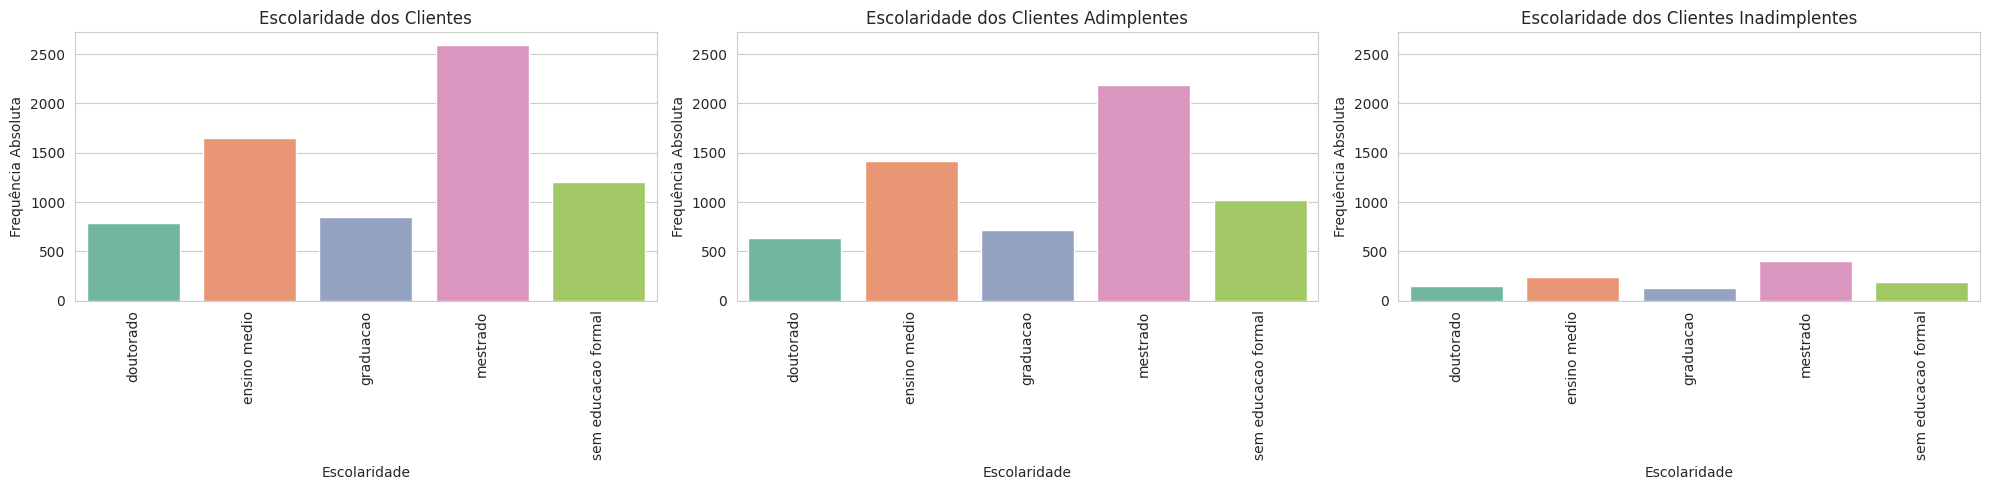

In [21]:
escolariade_grafico = comp_default_categ(df=df, coluna= 'escolaridade', titulos= ['Escolaridade dos Clientes', 'Escolaridade dos Clientes Adimplentes', 'Escolaridade dos Clientes Inadimplentes'])

Podemos notar que o atributo **Escolaridade** não é relevante para o objetivo do projeto, pois a distribuição se mantém semelhante nos três gráficos.

 - Estado Civil

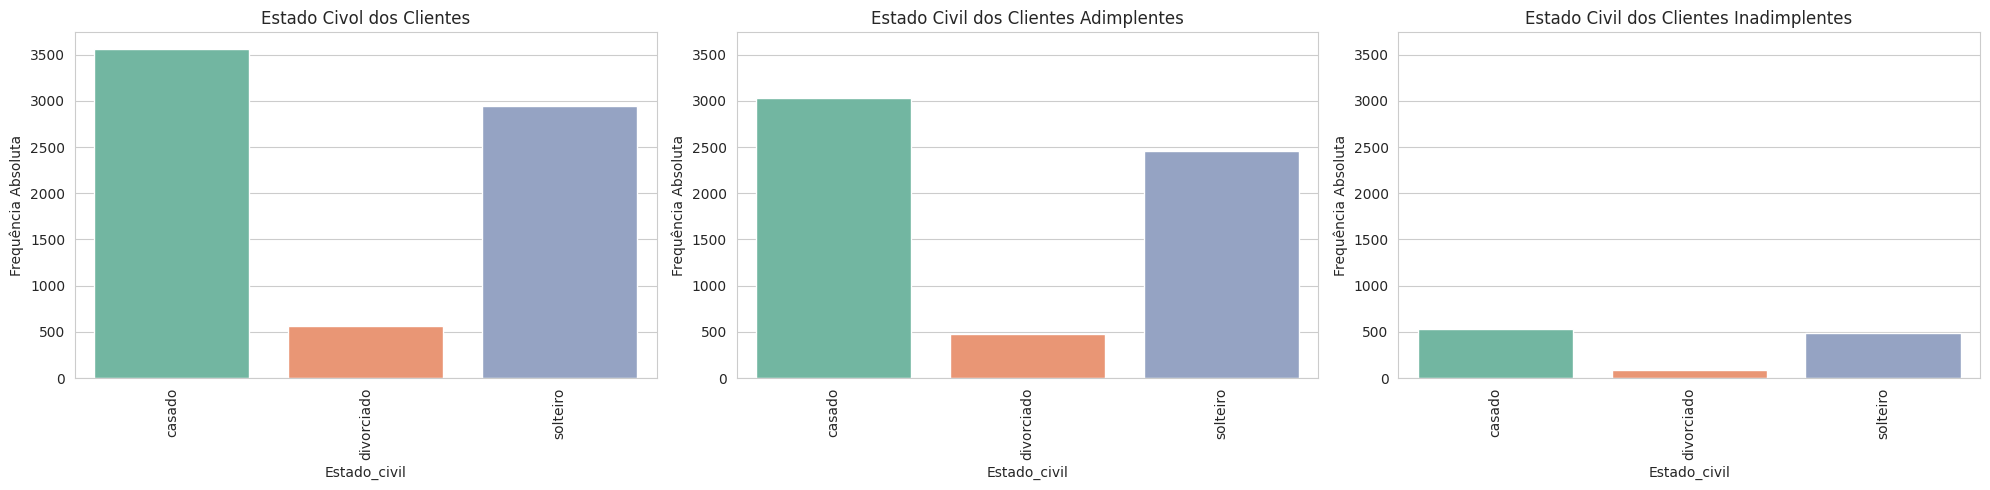

In [22]:
estdcvl_grafico = comp_default_categ(df=df, coluna= 'estado_civil', titulos= ['Estado Civol dos Clientes', 'Estado Civil dos Clientes Adimplentes', 'Estado Civil dos Clientes Inadimplentes'])

O atributo **Estado Civil** também se motra irrelevante para o objetivo do projeto, pois a distribuição também se mantém semelhante nos três gráficos.

 - Salário Anual

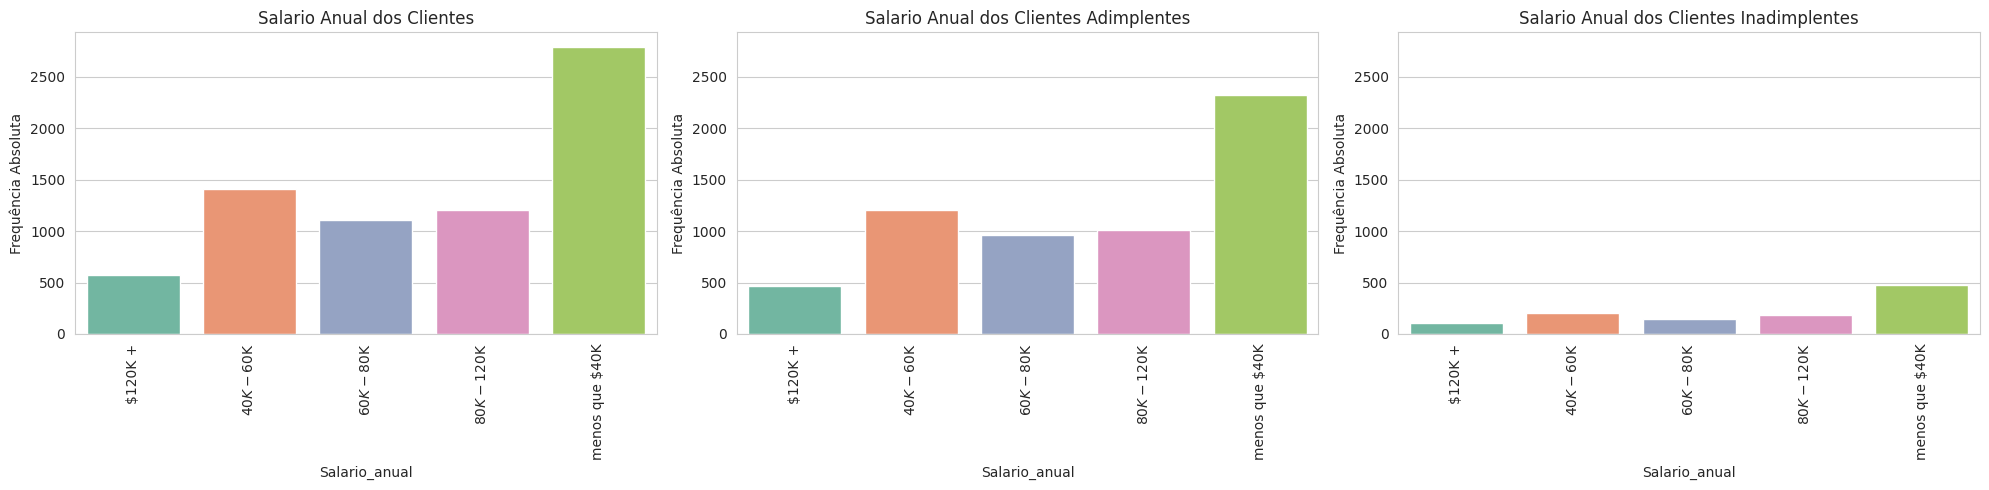

In [23]:
salario_grafico = comp_default_categ(df=df, coluna= 'salario_anual', titulos= ['Salario Anual dos Clientes', 'Salario Anual dos Clientes Adimplentes', 'Salario Anual dos Clientes Inadimplentes'])

O atributo **Salario Anual** também não é relevante para o nosso objetivo, a distribuição se mantém semelhante nos três gráficos.

 - Cartão de Credito

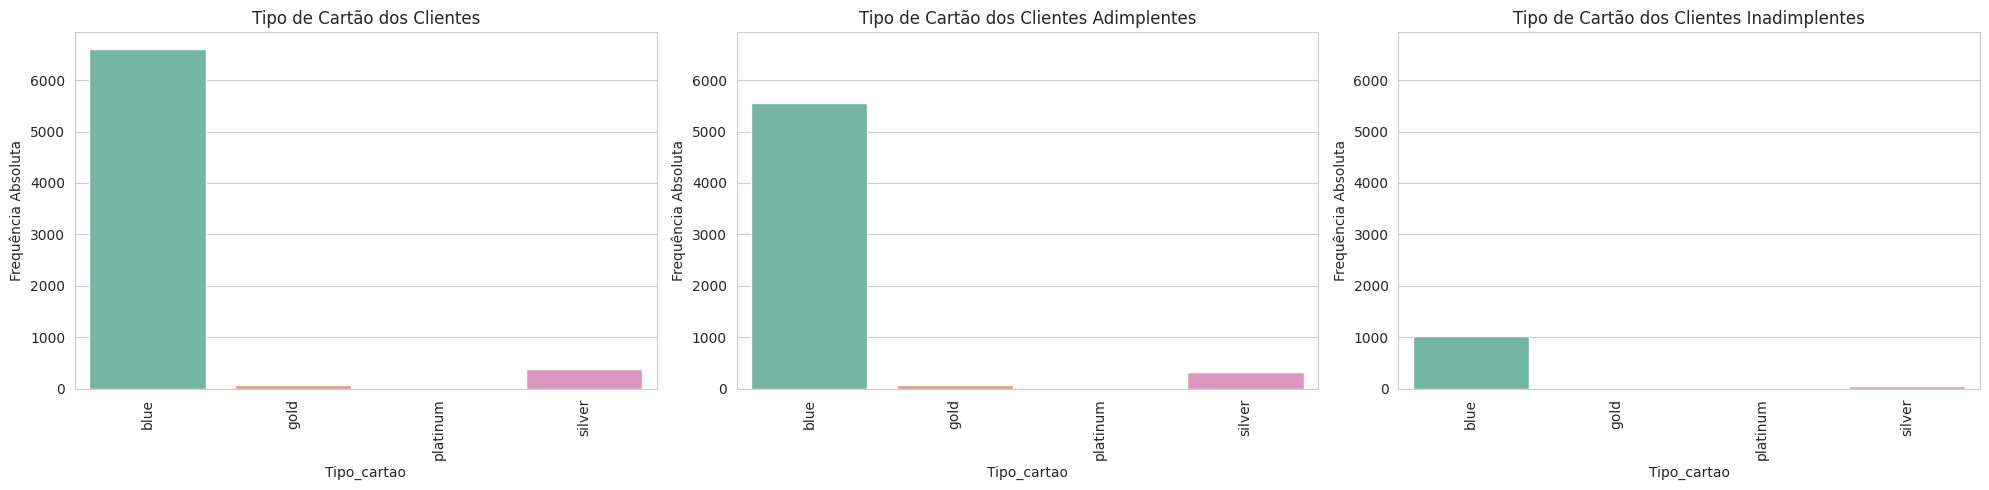

In [24]:
cartao_grafico = comp_default_categ(df=df, coluna= 'tipo_cartao', titulos= ['Tipo de Cartão dos Clientes', 'Tipo de Cartão dos Clientes Adimplentes', 'Tipo de Cartão dos Clientes Inadimplentes'])

No atributo **Tipo do Cartão** podemos notar algo interessante, são poucos os clientes que possuem o cartão gold, mas todos são adimplentes; e que não há clientes com cartão platinum na base de dados, mas isso não contribui com o nosso objetivo.

### 4.2.Viasualizações numericas

As informações recolhidas nos dados catégoricos não foram ulteis para nosso objetivo, estão vamos prosseguir e olhar os dados numericos

In [25]:
df.drop(['id', 'default'], axis=1).select_dtypes('number').head(n=5)

,idade,dependentes,meses_de_relacionamento,qtd_produtos,iteracoes_12m,meses_inativo_12m,limite_credito,valor_transacoes_12m,qtd_transacoes_12m
0,45,3,39,5,3,1,12691.51,1144.90,42
1,49,5,44,6,2,1,8256.96,1291.45,33
2,51,3,36,4,0,1,3418.56,1887.72,20
4,40,3,21,5,0,1,4716.22,816.08,28
5,44,2,36,3,2,1,4010.69,1088.07,24


Trazemos as inforações dos dados numericos, e ja temos salvos os dois grupos diferentes, adimplentes e inadimplentes, em variaveis para trabalharmos.

Vamos criar uma outra função para tranformar os dados de cada coluna desejada, agora para trabalhar nos dados numericos, e gerar os graficos para compara-los  com o `default`

In [26]:
# Silenciar warnings relacionados ao use_inf_as_na
warnings.filterwarnings("ignore", category=FutureWarning, message=".*use_inf_as_na.*")

def comp_default_num(df: pd.DataFrame, coluna: str, titulos: List[str]) -> None:
    df = df.replace([np.inf, -np.inf], np.nan)
    df_adimplente_proc = df_adimplente.replace([np.inf, -np.inf], np.nan)
    df_inadimplente_proc = df_inadimplente.replace([np.inf, -np.inf], np.nan)

    eixo = 0
    max_y = 0
    figura, eixos = plt.subplots(1, 3, figsize=(20, 5), sharex=True)

    for dataframe in [df, df_adimplente_proc, df_inadimplente_proc]:
        f = sns.histplot(x=coluna, data=dataframe, stat='count', ax=eixos[eixo])
        f.set(title=titulos[eixo], xlabel=coluna.capitalize(), ylabel='Frequência Absoluta')

        _, max_y_f = f.get_ylim()
        max_y = max(max_y, max_y_f)
        f.set(ylim=(0, max_y))

        eixo += 1

    plt.tight_layout()
    plt.show()

Agora, novamente, podemos aplicar nas colunas que desejamos

 - Quantidade de Transações nos Últimos 12 Meses

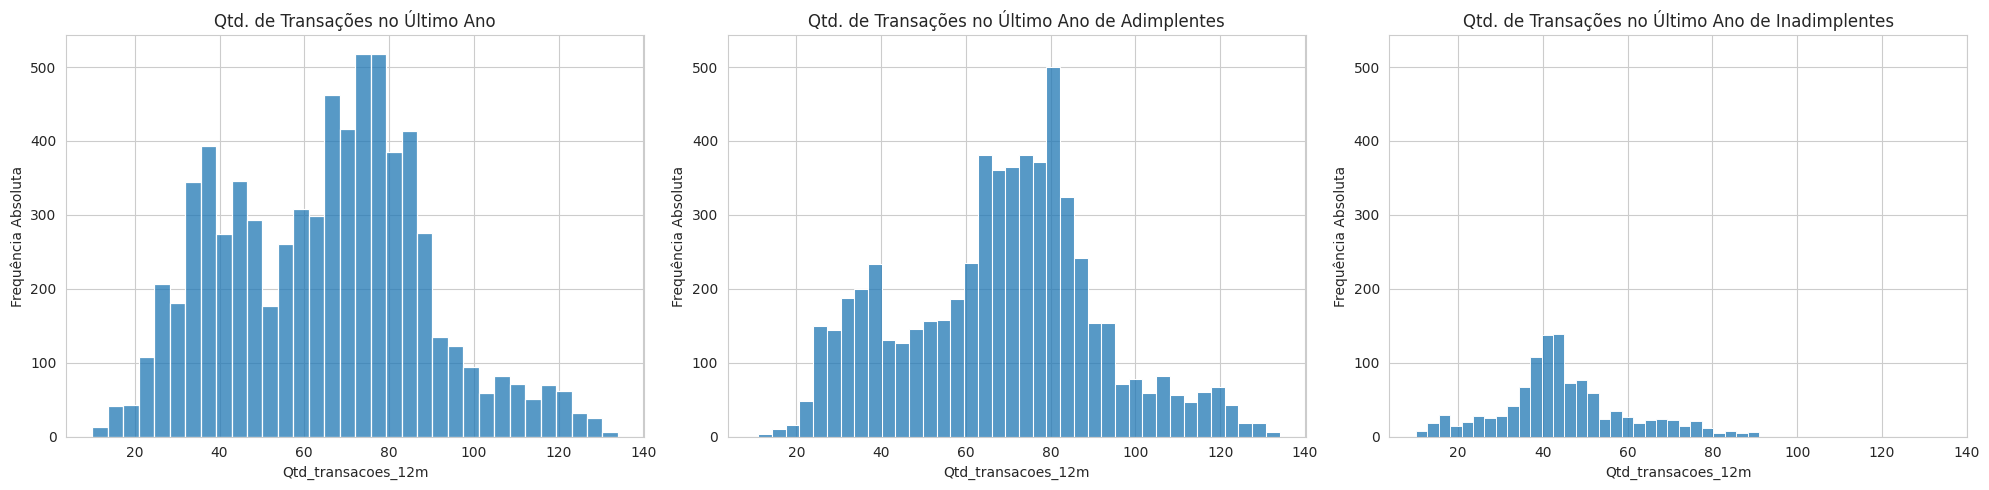

In [27]:
qtd_trans12m_grafico = comp_default_num(df=df, coluna= 'qtd_transacoes_12m', titulos= ['Qtd. de Transações no Último Ano', 'Qtd. de Transações no Último Ano de Adimplentes', 'Qtd. de Transações no Último Ano de Inadimplentes'])

Observando os gráficso podemos notar, que no que representa todos os clientes, temos dois picos: um em torno de 40 transações e outro em torno de 80 transações. Já quando avaliamos o gráfico de adimplentes, apesar de termos os dois piscos semelhantes, o pico que ocorre em torno de 40 transações parece mais suave. E, ao avaliarmos o gráfico dos inadimplentes vemos um pico em torno de 40 transações, completanto o que falta no gráfico dos clientes adimplentes. Assim podemos concluir que o atributo **Quantidade de Transações nos Últimos 12 Meses** tem relação com o obejtivo do projeto.

 - Valor das Transações nos Últimos 12 Meses

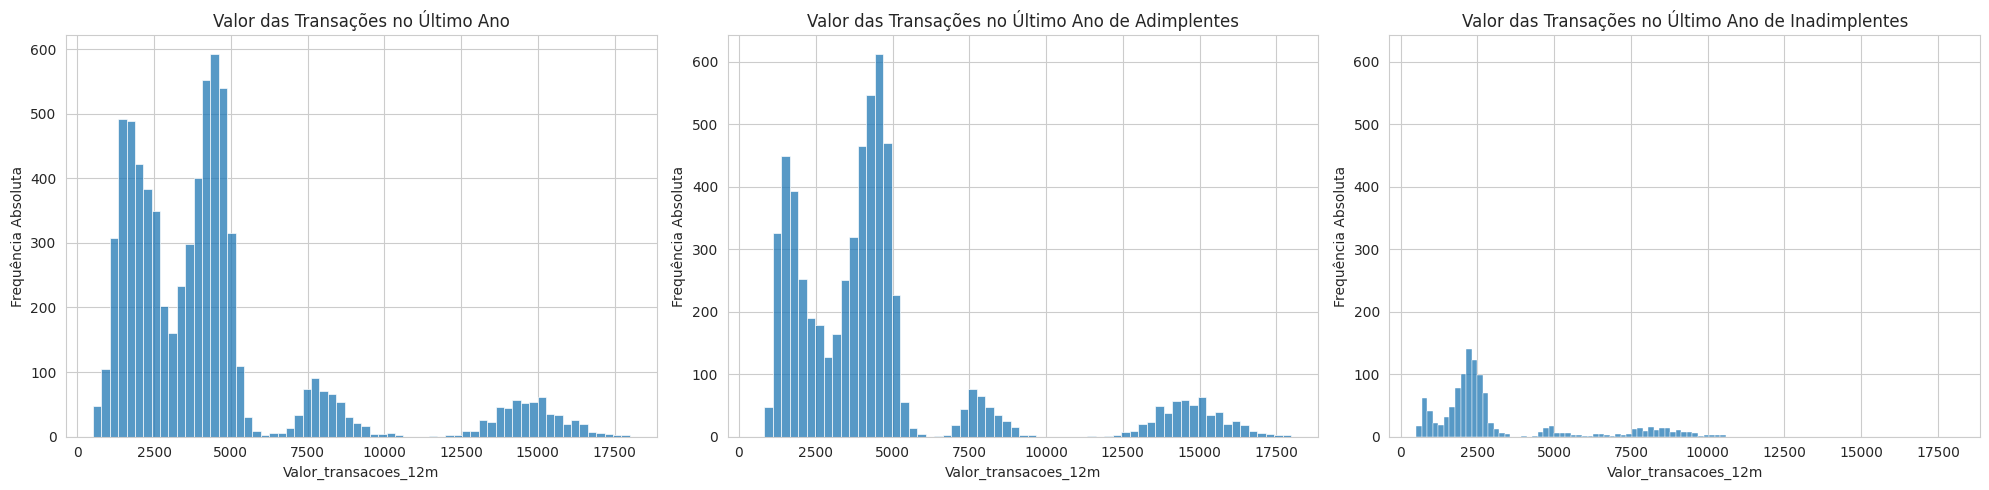

In [28]:
valor_trans12m_grafico = comp_default_num(df=df, coluna= 'valor_transacoes_12m', titulos= ['Valor das Transações no Último Ano', 'Valor das Transações no Último Ano de Adimplentes', 'Valor das Transações no Último Ano de Inadimplentes'])

Temos aqui algo semelhante com o que ocorrido no atributo **Quantidade de Transações nos Últimos 12 Meses**; podemos ver que no grafico dos clientes adimplentes, em torno de transações com valor de 2.500, o pico se suaviza mais uma vez em comparação com o total, e o que falta nele é complementado pelo pico que está no gráfico dos clientes inadimplentes.

 - Meses de Relacionamento com a Empresa

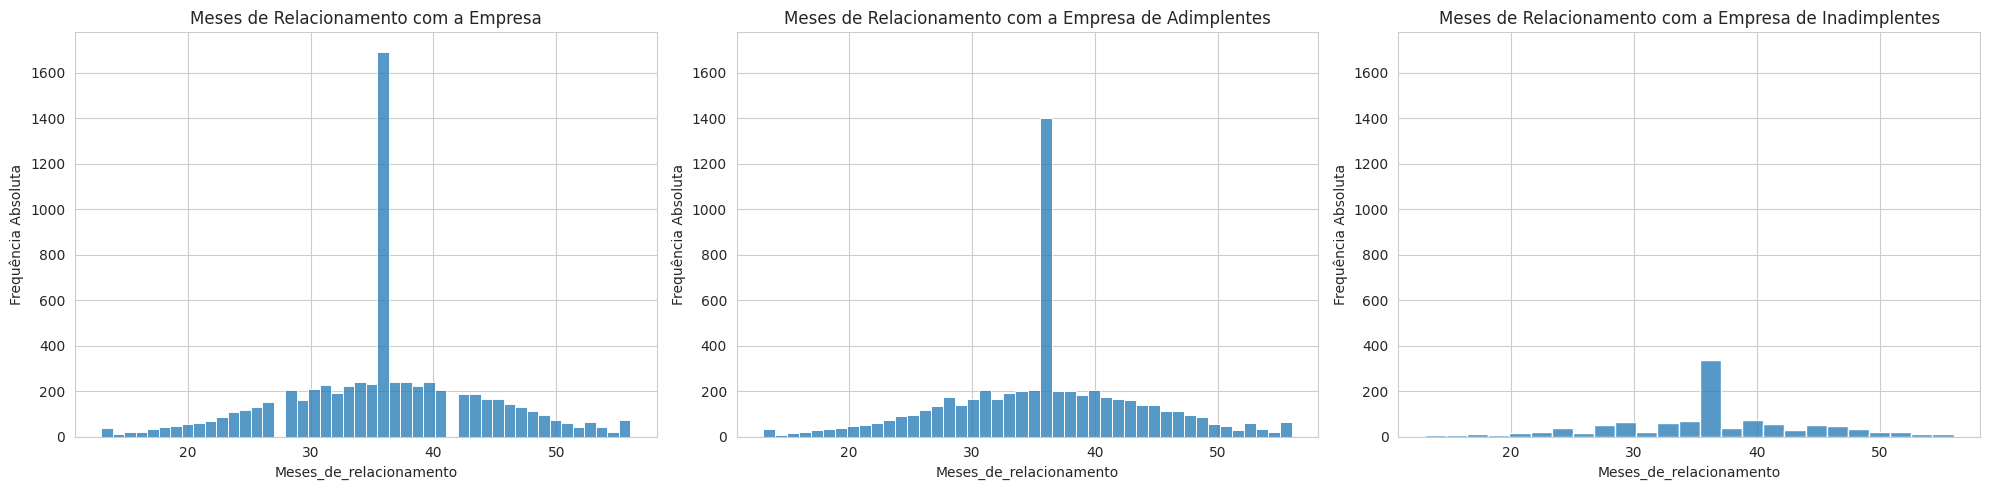

In [29]:
mes_relac_grafico = comp_default_num(df=df, coluna= 'meses_de_relacionamento', titulos= ['Meses de Relacionamento com a Empresa', 'Meses de Relacionamento com a Empresa de Adimplentes', 'Meses de Relacionamento com a Empresa de Inadimplentes'])

O atributo de **Meses de Relacionamento** aparenta não ser relevante para o objetivo do projeto, pois a distribuição se mantém semelhante nos três gráficos.

 - Idade

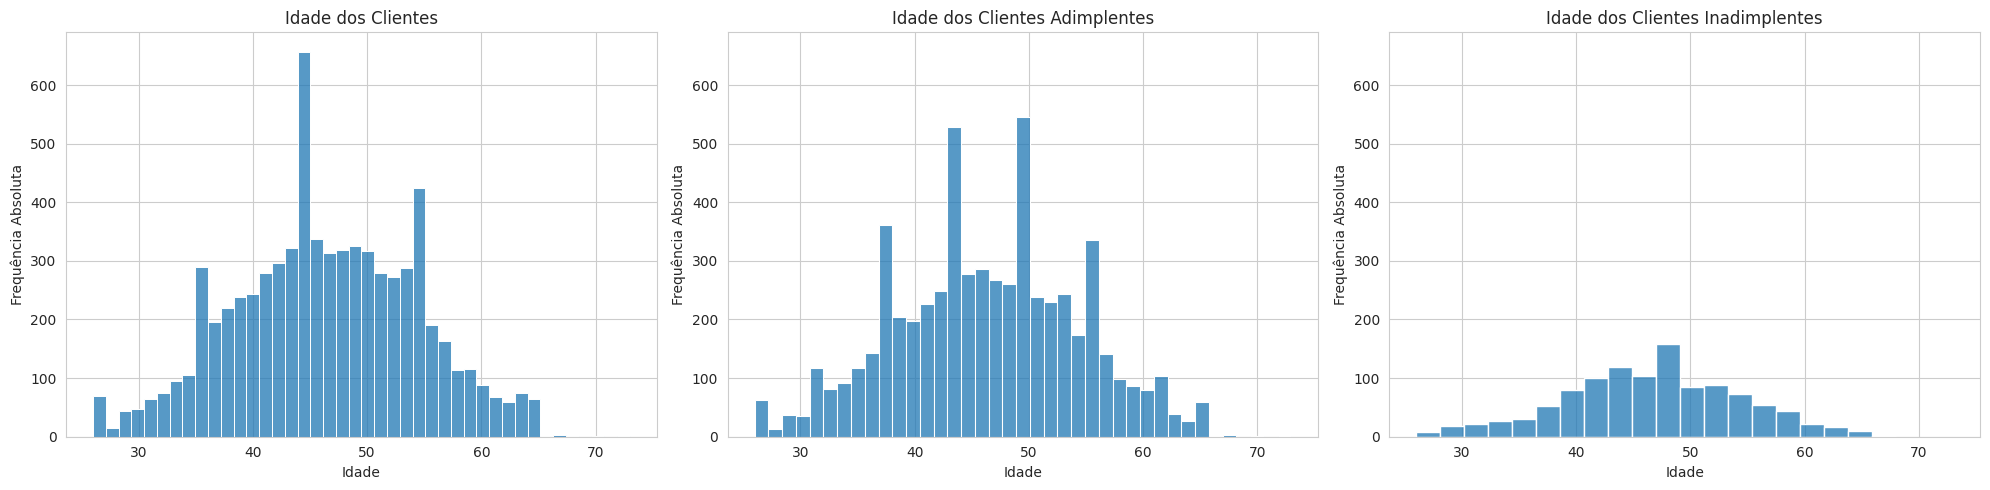

In [30]:
iade_grafico = comp_default_num(df=df, coluna= 'idade', titulos= ['Idade dos Clientes', 'Idade dos Clientes Adimplentes', 'Idade dos Clientes Inadimplentes'])

O atributo **Idade** também mantém a distribuição nos três gráficos, mas nos mostra também, que a media de clientes inadimplentes, está entre 40 e 50 anos.

 - Limite de Credito

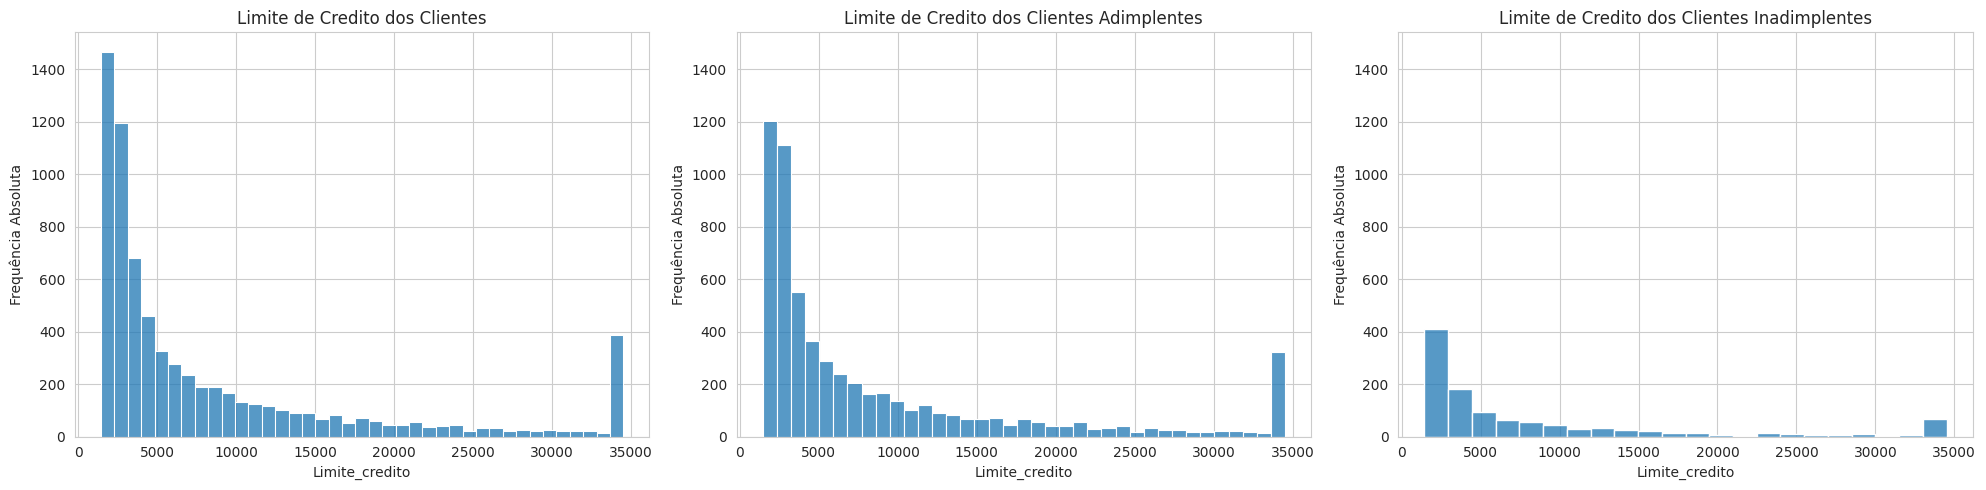

In [31]:
credito_grafico = comp_default_num(df=df, coluna= 'limite_credito', titulos= ['Limite de Credito dos Clientes', 'Limite de Credito dos Clientes Adimplentes', 'Limite de Credito dos Clientes Inadimplentes'])

O atributo de **Limite de Credito** também não é relevante para o nosso objetivo, a distribuição se mantém semelhante nos três gráficos.

Passamos nossos dados e já conseguimos identificar os dados relevantes e irrelevantes. E uma vez identificados dois atributos numéricos que têm relaçãco com o objetivo do projeto, podemos observar como default se divide ao considerarmos esses dois atributos juntos.


No caso vamos utlizar: Valor de Transações nos Últimos 12 Meses  x  Quantidade de Transações nos Últimos 12 Meses

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/tmp/ipykernel_13/2625119927.py:24: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


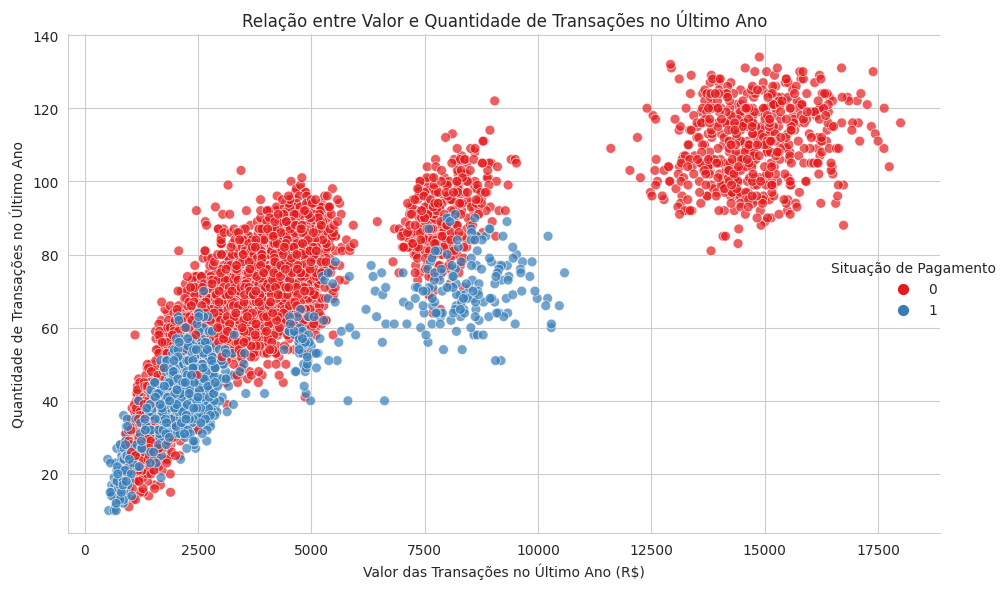

In [32]:
f = sns.relplot(
    data=df,
    x='valor_transacoes_12m',
    y='qtd_transacoes_12m',
    hue='default',
    palette='Set1',         
    size='default',          
    sizes=(50,50),         
    alpha=0.7,               
    height=6, aspect=1.5     
)


f.set(
    title='Relação entre Valor e Quantidade de Transações no Último Ano',
    xlabel='Valor das Transações no Último Ano (R$)',
    ylabel='Quantidade de Transações no Último Ano'
)


f._legend.set_title('Situação de Pagamento')
f._legend.set_bbox_to_anchor((1.05, 0.5))  

plt.tight_layout()
plt.show()

Observando o gráfico acima podemos concluir que há dois grupos separados que contém adimplentes e inadimplentes; e um grupo que só contém adimplentes.

Analisando os grupos que contém somente adimplentes podemos conluir que clientes com muitas transações (acima de 80) e com valores altos (acima de 12 Mil) tendem a ser adimplentes.

Analisando os grupos que possuem inadimplentes podemos chegar as seguintes combinações entre valor de transação e quantidade de transação:

Clientes com a Quantidade de transações abaixo de 60 e com valores abaixo de 3.500: tendência a Inadimplência

Clientes com a Quantidade de transações entre 60 e 90 com valores entre 3.500 e 1.500: tendência a Inadimplência

Clientes com a Quantidade de transações entre 60 e 100 com valores entre 3.000 e 5.000: tendência a Adimplência.

Clientes com a Quantidade de transações entre 90 e 120 com valores entre 7.500 e 9.000: tendência a adimplência.

Clientes com a Quantidade de transações entre 80 e 140 com valores entre 11.000 e 17.500: forte tendência a Adimplência.

# Conclusão

Após a exploração dos dados, a limpeza dos mesmos e a organizaçãp do schema, pudemos realizar a análise dos dados, com o objetivo de encontrar o motivo que leva um cliente da empresa a se tornar inadimplente

Tivemos que seguir A Lei Geral de Proteção de Dados Pessoais (LGPD), Lei n° 13.709/2018, Então não computamos valores relacionados a sexo, por exemplo.

Então Podemos concluir que os atributos categóricos não puderam mapear o comportamento de adimplência e inadimplência dos clientes da base de dados analisada. No entanto, quando avaliamos os atributos numéricos, pode-se destacar os seguintes pontos:

Há uma relação entre o **Valor de Transações nos Últimos 12 Meses** e a **Quantidade de Transações nos Últimos 12 Meses**, e chegamos a algumas combinações desses valores:

Clientes com a Quantidade de transações abaixo de 60 e com valores abaixo de 3.500: tendência a Inadimplência

Clientes com a Quantidade de transações entre 60 e 90 com valores entre 3.500 e 10.500: tendência a Inadimplência

Clientes com a Quantidade de transações entre 60 e 100 com valores entre 3.000 e 5.000: tendência a Adimplência.

Clientes com a Quantidade de transações entre 90 e 120 com valores entre 7.500 e 9.000: tendência a adimplência.

Clientes com a Quantidade de transações entre 80 e 140 com valores entre 11.000 e 17.500: forte tendência a Adimplência.

Vimos também que o atributo **Idades** nos mostrou que exite uma media nos clientes, entre 40 e 50 anos, são cliente com tendência a ser inadimplentes.

#### - Consiferação final

Fica então esclarecido, após analise, que essa empresa deve focar os seus esforços nos clientes que possuem uma faixa de transação entre as 30 a 80 transações anuais e os clientes que transacionam valores entre 1.000 a 3.000, 5.000 e 7.500 a 10.000, para que esses cliente não venham a se tornar inadimplestes.